In [13]:
import warnings
warnings.filterwarnings("ignore")
import logging
# Suppress INFO logs, show only WARNING and above
logging.getLogger().setLevel(logging.WARNING)


from repspat import SampleData, spatial_silhouette_analysis,spatial_constrained_hac, plot_spatial_clusters, plot_cluster_feature_presence, pairwise_results_to_matrix, multiple_comparison, create_blocks


In [14]:
thresholds = {
    "betaCatenin": 0.253063192,
    "CD11b": 1.100536222,
    "CD11c": 0.213556566,
    "CD138": 1.038502303,
    "CD16": 0.304460727,
    "CD20": 0.296460556,
    "CD209": 0.406669859,
    "CD3": 0.250762424,
    "CD31": 1.006381212,
    "CD4": 0.223762,
    "CD45": 0.327450495,
    "CD45RO": 0.236334141,
    "CD56": 0.770183826,
    "CD63": 0.268126101,
    "CD68": 1.128510101,
    "CD8": 0.260237333,
    "dsDNA": 0.20301697,
    "EGFR": 1.069264889,
    "FoxP3": 0.34649899,
    "H3K27me3": 0.201893232,
    "H3K9ac": 0.406071229,
    "HLA_Class_1": 0.23773137,
    "HLADR": 0.4408116,
    "IDO": 0.312824202,
    "Keratin17": 0.291843697,
    "Keratin6": 0.282480556,
    "Ki67": 0.210413737,
    "Lag3": 1.239097091,
    "MPO": 0.324934545,
    "p53": 0.265704293,
    "panKeratin": 0.244129571,
    "PD1": 0.972859909,
    "PDL1": 1.352024101,
    "pS6": 0.282699091,
    "SMA": 0.250358024,
    "Vimentin": 0.28239596
}

In [15]:
data = SampleData(sample_column="sample_id", sample_name="Sample_04",adata_path='../data/03_TNBC_2018_spe.h5ad', thresholds=thresholds)

In [16]:
data.summary()

{'feature_mat': (5381, 36),
 'coords_mat': (5381, 2),
 'dist_matrix': (5381, 5381),
 'cell_type': (5381, 1),
 'sample_adata': (5381, 36)}

In [17]:
data.feature_mat

,betaCatenin,CD11b,CD11c,CD138,CD16,CD20,CD209,CD3,CD31,CD4,...,Ki67,Lag3,MPO,p53,panKeratin,PD1,PDL1,pS6,SMA,Vimentin
Cell_1405,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
Cell_1406,0,0,1,0,0,1,0,1,0,1,...,0,0,0,0,0,0,0,1,0,1
Cell_1407,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
Cell_1408,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
Cell_1409,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cell_178418,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
Cell_178419,0,0,1,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,1,0,1
Cell_178420,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,1
Cell_178421,0,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,1,0,1


In [18]:
spatial_silhouette_analysis(data, n_neighbors_list=[6,8], n_clusters_range=range(4,9))

INFO     Creating graph using `None` transform and `1` libraries.                                                  
INFO     Creating graph using `None` transform and `1` libraries.                                                  


,n_neighbors,n_clusters,avg_silhouette
0,6,4,0.108214
1,6,5,0.088461
2,6,6,0.116616
3,6,7,0.156908
4,6,8,0.169332
5,8,4,0.200711
6,8,5,0.191113
7,8,6,0.197577
8,8,7,0.203478
9,8,8,0.111283


In [19]:
labels, feature_df, model = spatial_constrained_hac(data.sample_adata, feature_df=data.feature_mat, n_clusters=7, n_neighs=8)

INFO     Creating graph using `None` transform and `1` libraries.                                                  


In [20]:
x = data.coords_mat.centroidX
y = data.coords_mat.centroidY

(<Figure size 400x400 with 1 Axes>,
 <Axes: title={'center': 'Spatial Plot of Cells with Cluster Colors'}, xlabel='X coordinate', ylabel='Y coordinate'>)

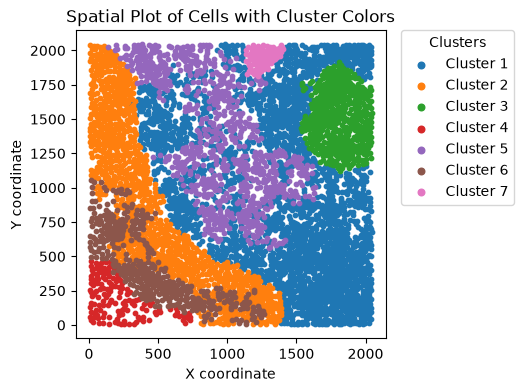

In [21]:
plot_spatial_clusters(x,y,labels=labels )

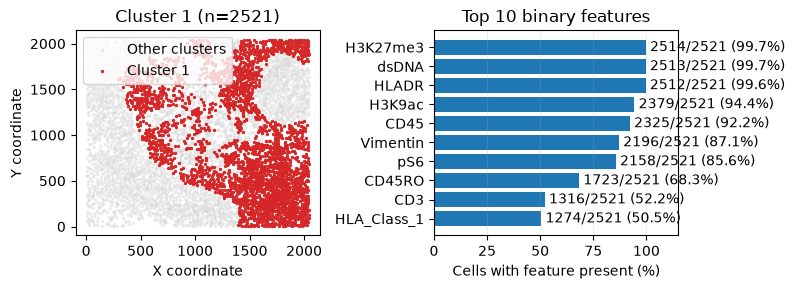

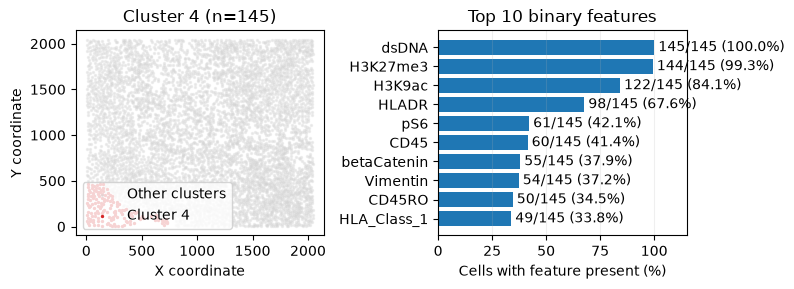

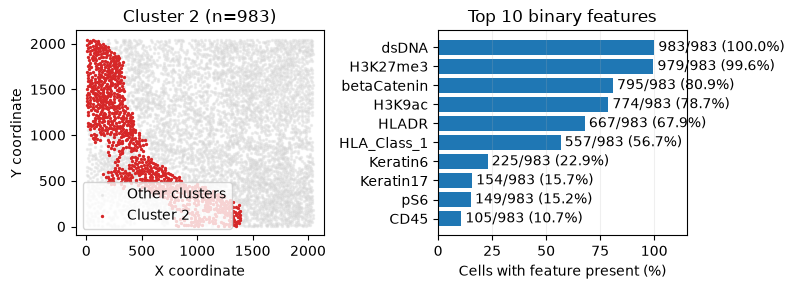

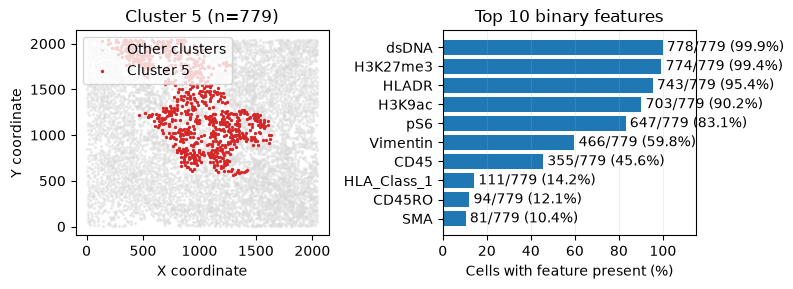

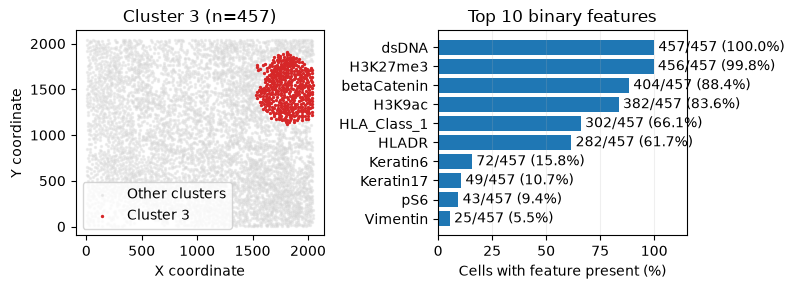

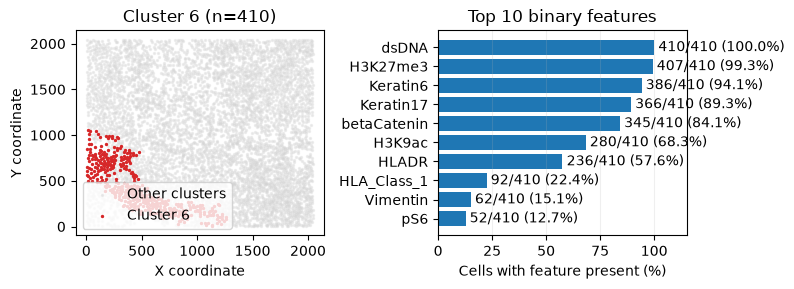

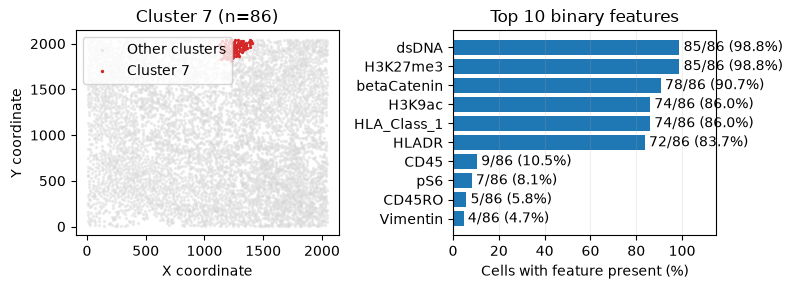

In [26]:
cluster_feature_plots = plot_cluster_feature_presence(
    x, y, labels, feature_df, top_n=10, point_size=2
)

In [11]:
blocked_data = create_blocks(data.feature_mat, 36, 8)

In [12]:
results_df = multiple_comparison(blocked_data, data.dist_matrix, kernel='IMQ')

KeyboardInterrupt: 

In [ ]:
results_df[results_df['adj_p'] >= 0.05]

,region_1,region_2,obs_mmd_sq,p_value,null_dist,adj_p
0,1,4,0.111754,0.210,"[0.07231019855928056, 0.11911186478048258, 0.0...",0.294000
6,4,2,0.070053,0.780,"[0.08261922503900232, 0.08015971064119554, 0.0...",0.910000
7,4,5,0.103851,0.505,"[0.06892358703315632, 0.15313108277425724, 0.0...",0.623824
8,4,3,0.113814,0.385,"[0.08066485227305442, 0.24991503103484702, 0.0...",0.505313
12,2,3,0.010092,1.000,"[0.0718967341203226, 0.15219518455402137, 0.01...",1.000000
14,2,7,0.063537,0.890,"[0.1883823877310179, 0.08145115575574013, 0.11...",0.981750
19,3,7,0.039111,0.935,"[0.10986147990971473, 0.14673569917944618, 0.0...",0.981750


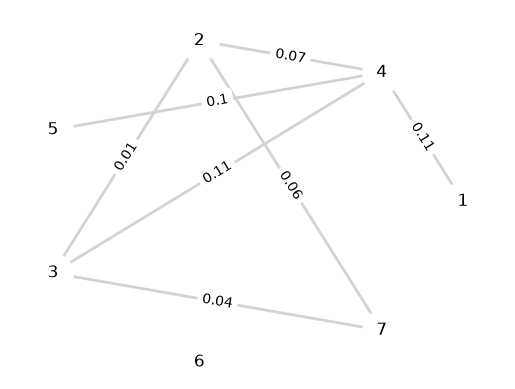

,1,4,2,5,3,6,7
1,0.000000,0.111754,0.000000,0.000000,0.000000,0.0,0.000000
4,0.111754,0.000000,0.070053,0.103851,0.113814,0.0,0.000000
2,0.000000,0.070053,0.000000,0.000000,0.010092,0.0,0.063537
5,0.000000,0.103851,0.000000,0.000000,0.000000,0.0,0.000000
3,0.000000,0.113814,0.010092,0.000000,0.000000,0.0,0.039111
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
7,0.000000,0.000000,0.063537,0.000000,0.039111,0.0,0.000000


In [ ]:
pairwise_results_to_matrix(results_df)